# Laboratorio 7
### Modelos de Regresión Logística
- Fabian Prado #23427
- Sofia Lopez #231929
- Jonathan Zacarias #231104
- repo: https://github.com/fabianpradod/lab7-mineria
---

## Contexto

En esta quinta entrega de consultoría para **SmartStay Advisors** aplicamos Regresión Logística tanto en su variante binaria (¿es cara una propiedad?) como multinomial (clasificación en *Económica*, *Intermedia* y *Cara*). Se mantienen los mismos conjuntos de entrenamiento y prueba de todas las entregas anteriores para garantizar comparaciones válidas entre algoritmos.

In [2]:
import time
import io
import pstats
import pyreadr
import warnings
import cProfile
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold, learning_curve
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score,
    roc_curve, auc, roc_auc_score
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
SEED = 42

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f9f9f9',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'font.family':      'sans-serif',
})

---
## Lectura y preparación de datos

Se reutiliza exactamente el mismo pipeline de limpieza, selección de variables, split 80/20 y escalado de las entregas anteriores. Esto garantiza que cualquier comparación de métricas entre algoritmos sea válida.

In [3]:
result = pyreadr.read_r('../data/listings.RData')
listings_df = list(result.values())[0]
print(f'Dataset cargado: {listings_df.shape[0]:,} filas x {listings_df.shape[1]} columnas')

def clean_price(val):
    if pd.isna(val): return np.nan
    cleaned = str(val).replace('$', '').replace(',', '').strip()
    if not cleaned: return np.nan
    try: return float(cleaned)
    except ValueError: return np.nan

def clean_rate(val):
    if pd.isna(val): return np.nan
    cleaned = str(val).replace('%', '').strip()
    if not cleaned or cleaned.upper() == 'N/A': return np.nan
    try: return float(cleaned) / 100
    except ValueError: return np.nan

def encode_bool(val):
    if pd.isna(val): return np.nan
    return 1 if str(val).strip().lower() in ('t', 'true', '1') else 0

listings_df['price']               = listings_df['price'].apply(clean_price)
listings_df['host_response_rate']  = listings_df['host_response_rate'].apply(clean_rate)
listings_df['host_acceptance_rate']= listings_df['host_acceptance_rate'].apply(clean_rate)

for col in ['host_is_superhost', 'host_has_profile_pic',
            'host_identity_verified', 'instant_bookable', 'has_availability']:
    if col in listings_df.columns:
        listings_df[col] = listings_df[col].apply(encode_bool)

resp_map = {'within an hour': 1, 'within a few hours': 2,
            'within a day': 3, 'a few days or more': 4}
if 'host_response_time' in listings_df.columns:
    listings_df['host_response_time'] = listings_df['host_response_time'].map(resp_map)

if 'estimated_occupancy_l365d' not in listings_df.columns and 'number_of_reviews_l365d' in listings_df.columns:
    listings_df['estimated_occupancy_l365d'] = listings_df['number_of_reviews_l365d'] * 3.5

priced_listings_df = listings_df.dropna(subset=['price']).copy()
priced_listings_df = priced_listings_df[priced_listings_df['price'] > 0].copy()
print(f'Registros con precio válido: {priced_listings_df.shape[0]:,}')

Dataset cargado: 171,748 filas x 80 columnas
Registros con precio válido: 76,246


In [4]:
NUMERIC_FEATURES = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'host_total_listings_count', 'calculated_host_listings_count',
    'host_response_rate', 'host_acceptance_rate', 'host_response_time',
    'minimum_nights', 'maximum_nights',
    'availability_365', 'estimated_occupancy_l365d',
    'host_is_superhost', 'host_has_profile_pic',
    'host_identity_verified', 'instant_bookable', 'has_availability'
]
CAT_FEATURES = ['room_type', 'city']

NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in priced_listings_df.columns]
CAT_FEATURES     = [c for c in CAT_FEATURES     if c in priced_listings_df.columns]

df_model = pd.get_dummies(
    priced_listings_df[NUMERIC_FEATURES + CAT_FEATURES + ['price']],
    columns=CAT_FEATURES, drop_first=False
)

X = df_model.drop(columns=['price'])
y = df_model['price']

# ── Variable categórica — mismos terciles de entregas anteriores ─────────────
q1 = priced_listings_df['price'].quantile(0.25)
q3 = priced_listings_df['price'].quantile(0.75)
print(f'Q1 (25%): ${q1:.2f}  |  Q3 (75%): ${q3:.2f}')

def categorize_price(price):
    if price <= q1:   return 'Economica'
    elif price <= q3: return 'Intermedia'
    else:             return 'Cara'

# ── Split 80/20 — SEED=42, idéntico a todas las entregas ────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f'Train: {X_train.shape[0]:,} filas  |  Test: {X_test.shape[0]:,} filas')

y_cat_train = y_train.apply(categorize_price)
y_cat_test  = y_test.apply(categorize_price)

print('\nDistribución en entrenamiento:')
print(y_cat_train.value_counts(normalize=True).map('{:.1%}'.format))

# ── Imputación y escalado ────────────────────────────────────────────────────
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

print('\nImputación y escalado aplicados correctamente.')

Q1 (25%): $120.00  |  Q3 (75%): $326.00
Train: 60,996 filas  |  Test: 15,250 filas

Distribución en entrenamiento:
price
Intermedia    49.6%
Economica     25.5%
Cara          24.9%
Name: proportion, dtype: object

Imputación y escalado aplicados correctamente.


---
## Variables dicotómicas por categoría de precio

Para aplicar regresión logística binaria se crean tres variables indicadoras a partir de la variable categórica de precio: una por cada segmento. Cada variable toma valor **1** si la propiedad pertenece a esa categoría y **0** en caso contrario.

In [5]:
# Variable dicotómica: Cara vs no-Cara
y_cara_train = (y_cat_train == 'Cara').astype(int)
y_cara_test  = (y_cat_test  == 'Cara').astype(int)

# Variable dicotómica: Intermedia vs no-Intermedia
y_media_train = (y_cat_train == 'Intermedia').astype(int)
y_media_test  = (y_cat_test  == 'Intermedia').astype(int)

# Variable dicotómica: Economica vs no-Economica
y_eco_train = (y_cat_train == 'Economica').astype(int)
y_eco_test  = (y_cat_test  == 'Economica').astype(int)

resumen = pd.DataFrame({
    'Variable':      ['Cara', 'Intermedia', 'Economica'],
    'Positivos train': [y_cara_train.sum(), y_media_train.sum(), y_eco_train.sum()],
    'Negativos train': [(y_cara_train==0).sum(), (y_media_train==0).sum(), (y_eco_train==0).sum()],
    'Positivos test':  [y_cara_test.sum(),  y_media_test.sum(),  y_eco_test.sum()],
    'Negativos test':  [(y_cara_test==0).sum(),  (y_media_test==0).sum(),  (y_eco_test==0).sum()],
})
print(resumen.to_string(index=False))

  Variable  Positivos train  Negativos train  Positivos test  Negativos test
      Cara            15218            45778            3836           11414
Intermedia            30254            30742            7628            7622
 Economica            15524            45472            3786           11464


---
## Modelo de Regresión Logística Binaria: ¿Es cara una propiedad?

Se entrena un modelo de regresión logística para predecir si una propiedad pertenece al segmento *Cara* (precio > $326). Se utiliza validación cruzada estratificada con 5 folds para estimar el desempeño de forma robusta, y se fija `random_state=42` para garantizar reproducibilidad. El umbral de decisión inicial es 0.5.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

lr_bin = LogisticRegression(max_iter=1000, random_state=SEED, solver='lbfgs')

cv_scores = cross_val_score(lr_bin, X_train_sc, y_cara_train,
                             cv=cv, scoring='accuracy')

print(f'Accuracy CV (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Scores por fold: {[f"{s:.4f}" for s in cv_scores]}')

# Entrenamos sobre todo el train para análisis de coeficientes
lr_bin.fit(X_train_sc, y_cara_train)
print('\nModelo entrenado correctamente.')

Accuracy CV (5-fold): 0.8358 ± 0.0023
Scores por fold: ['0.8332', '0.8334', '0.8373', '0.8357', '0.8392']

Modelo entrenado correctamente.


=== Top 15 variables por magnitud de coeficiente ===
                   Feature  Coeficiente  Odds Ratio
                 bathrooms     0.782937    2.187888
              accommodates     0.662354    1.939352
 estimated_occupancy_l365d    -0.544274    0.580263
        city_Austin, Texas    -0.404580    0.667257
 host_total_listings_count     0.338190    1.402407
     room_type_Shared room    -0.336755    0.714084
               city_Hawaii     0.318428    1.374965
                  bedrooms     0.284477    1.329067
     city_Washington, D.C.    -0.262498    0.769128
      room_type_Hotel room     0.225612    1.253090
         city_Rhode Island     0.220669    1.246911
            minimum_nights    -0.189704    0.827204
city_Boston, Massachusetts     0.188739    1.207726
        host_response_time     0.182678    1.200428
    city_Chicago, Illinois    -0.118226    0.888495


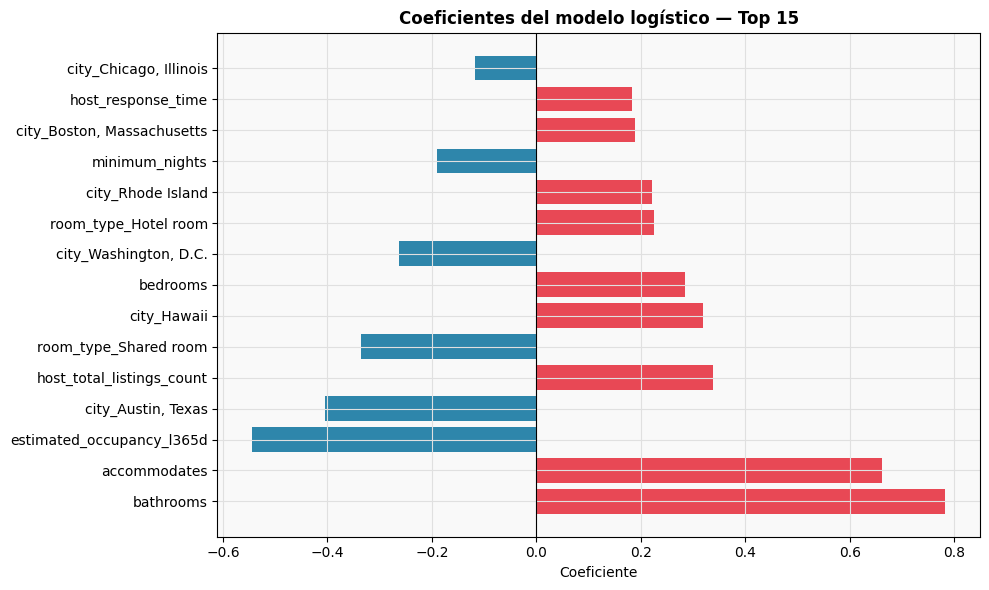

In [7]:
feature_names = X.columns.tolist()

coef_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coeficiente': lr_bin.coef_[0],
    'Odds Ratio':  np.exp(lr_bin.coef_[0])
}).sort_values('Coeficiente', key=abs, ascending=False)

print('=== Top 15 variables por magnitud de coeficiente ===')
print(coef_df.head(15).to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))
top15 = coef_df.head(15)
colors = ['#E84855' if c > 0 else '#2E86AB' for c in top15['Coeficiente']]
ax.barh(top15['Feature'], top15['Coeficiente'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes del modelo logístico — Top 15', fontweight='bold')
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

In [8]:
# VIF sobre una muestra para eficiencia computacional
sample_idx = np.random.RandomState(SEED).choice(X_train_sc.shape[0], size=5000, replace=False)
X_vif = pd.DataFrame(X_train_sc[sample_idx], columns=feature_names)

vif_data = pd.DataFrame({
    'Feature': feature_names,
    'VIF':     [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print('=== Factor de Inflación de Varianza (VIF) ===')
print(vif_data.to_string(index=False))
print('\nVIF > 10 indica multicolinealidad problemática.')
print(f'Variables con VIF > 10: {(vif_data["VIF"] > 10).sum()}')

=== Factor de Inflación de Varianza (VIF) ===
                       Feature      VIF
         city_Washington, D.C.      inf
     room_type_Entire home/apt      inf
    city_San Diego, California      inf
             city_Rhode Island      inf
                   city_Hawaii      inf
        city_Chicago, Illinois      inf
    city_Boston, Massachusetts      inf
            city_Austin, Texas      inf
         room_type_Shared room      inf
        room_type_Private room      inf
          room_type_Hotel room      inf
                      bedrooms 5.302809
                  accommodates 4.136078
                          beds 3.608780
                     bathrooms 2.758359
            host_response_time 2.003534
            host_response_rate 1.721776
calculated_host_listings_count 1.549481
          host_acceptance_rate 1.528642
     estimated_occupancy_l365d 1.411515
              instant_bookable 1.402075
     host_total_listings_count 1.343568
             host_is_superhost 1.2

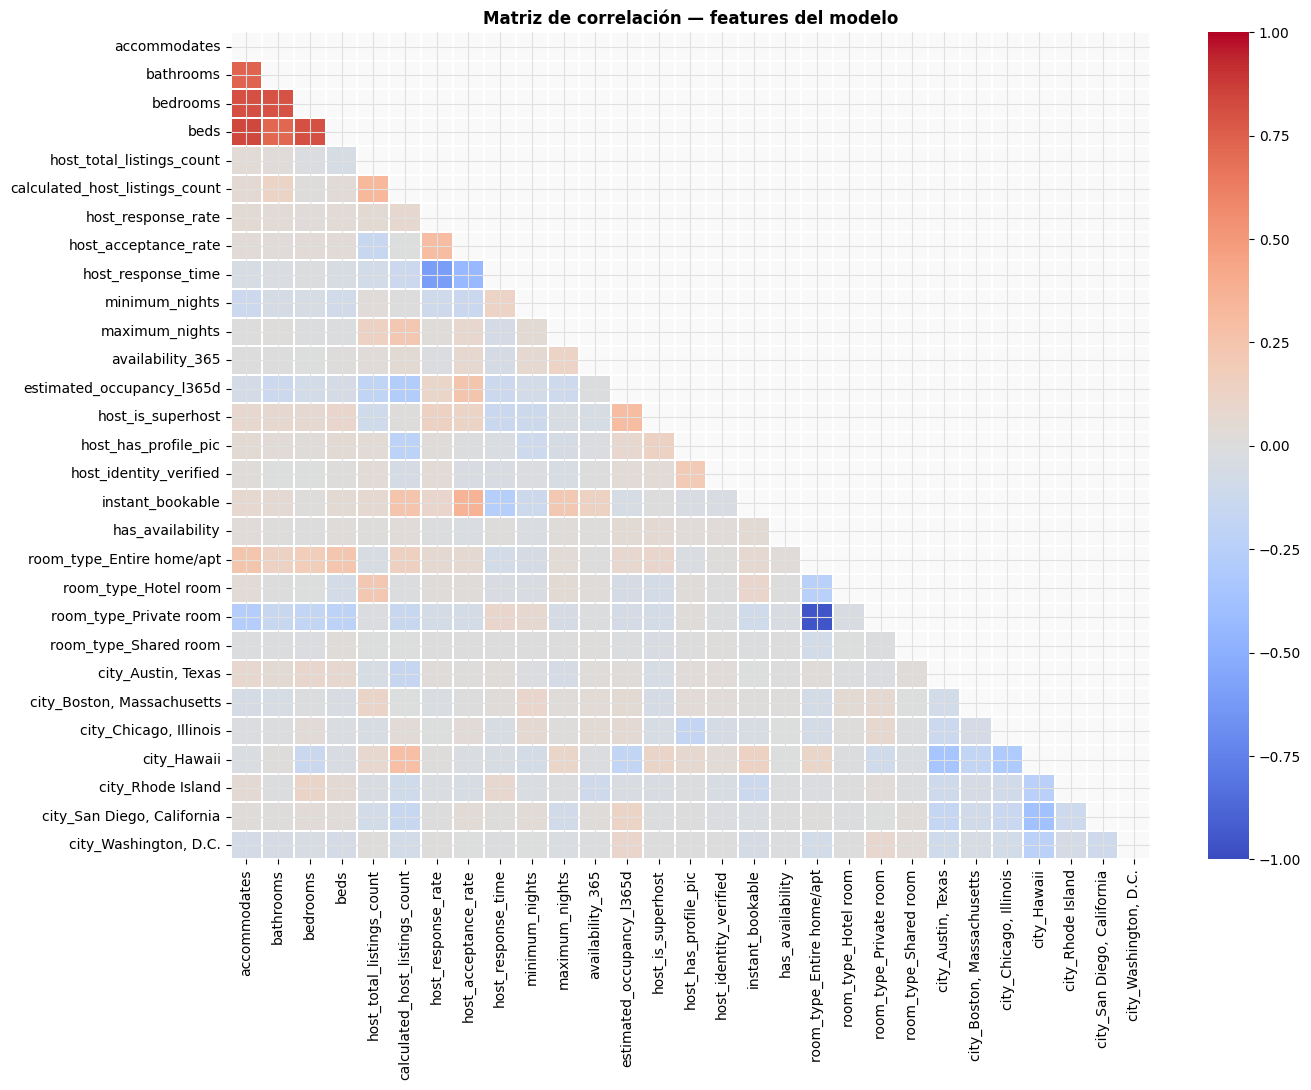


Pares con correlación |r| > 0.7:
  room_type_Entire home/apt — room_type_Private room: -0.955
  accommodates — beds: 0.838
  accommodates — bedrooms: 0.811
  bedrooms — beds: 0.809
  bathrooms — bedrooms: 0.799
  accommodates — bathrooms: 0.739
  bathrooms — beds: 0.723


In [9]:
X_sample = pd.DataFrame(X_train_sc[:3000], columns=feature_names)
corr = X_sample.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Matriz de correlación — features del modelo', fontweight='bold')
plt.tight_layout()
plt.show()

# Pares con correlación alta
high_corr = (corr.abs() > 0.7) & (corr != 1.0)
pairs = [(corr.columns[i], corr.columns[j], corr.iloc[i,j])
         for i in range(len(corr.columns))
         for j in range(i+1, len(corr.columns))
         if abs(corr.iloc[i,j]) > 0.7]

if pairs:
    print(f'\nPares con correlación |r| > 0.7:')
    for f1, f2, r in sorted(pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {f1} — {f2}: {r:.3f}')
else:
    print('\nNo se encontraron pares con correlación |r| > 0.7')

### Análisis del modelo logístico binario

**Desempeño con validación cruzada**

El modelo obtiene un Accuracy promedio de **83.58% ± 0.23%** en validación cruzada de 5 folds. La varianza entre folds es mínima (±0.23%), lo que indica que el modelo es estable y no depende del subconjunto particular de entrenamiento. Para una clasificación binaria donde la clase positiva (*Cara*) representa solo el 24.9% del conjunto de entrenamiento, este nivel de accuracy es una señal inicial positiva, aunque más adelante se deben evaluar métricas adicionales como precisión, recall y AUC que son más informativas ante desbalance de clases.

**Coeficientes e interpretación**

Las variables con mayor impacto positivo sobre la probabilidad de que una propiedad sea cara son **bathrooms** (coef = 0.783, OR = 2.19) y **accommodates** (coef = 0.662, OR = 1.94). En términos de odds ratios: cada unidad adicional de baños casi duplica las probabilidades de ser clasificada como cara, y cada persona adicional de capacidad las incrementa un 94%. Esto es consistente con la lógica del mercado — propiedades más grandes y con más baños justifican precios más altos.

Por el lado negativo, **estimated_occupancy_l365d** (coef = −0.544) y **city_Austin, Texas** (coef = −0.405) reducen la probabilidad de ser cara. El primer resultado es contraintuitivo a primera vista: propiedades con mayor ocupación estimada tienden a ser clasificadas como *no caras*. Esto puede explicarse porque las propiedades económicas e intermedias acumulan más reservas por su accesibilidad de precio, mientras que las caras tienen menor volumen de ocupación pero mayor ingreso por noche.

La variable **city_Hawaii** (coef = +0.318) eleva la probabilidad de ser cara, coherente con el mercado inmobiliario de Hawaii. Por otro lado, **city_Washington D.C.** y **city_Chicago** tienen coeficientes negativos, sugiriendo que en esas ciudades predominan propiedades de precio medio-bajo dentro del dataset.

**Multicolinealidad (VIF)**

Las 11 variables con VIF = ∞ corresponden a las dummies de `room_type` y `city`. Este resultado es esperado y se debe a la **trampa de variables dummy**: al incluir todas las categorías de una variable categórica sin eliminar una como referencia (`drop_first=False`), las columnas suman exactamente 1 por fila, creando dependencia lineal perfecta. La multicolinealidad en estos casos no afecta la capacidad predictiva del modelo, pero infla los errores estándar de los coeficientes individuales de esas variables. Para las variables numéricas continuas, los VIF oscilan entre 1.0 y 5.3, valores todos por debajo del umbral de 10 — indicando que entre ellas no hay multicolinealidad problemática.

**Correlación entre features**

El heatmap confirma lo que el VIF señaló: el bloque más correlacionado es el de tamaño físico de la propiedad. Los pares `accommodates–beds` (r = 0.838), `accommodates–bedrooms` (r = 0.811) y `bedrooms–beds` (r = 0.809) forman un cluster de alta colinealidad entre variables continuas. Esto tiene sentido: propiedades con más capacidad naturalmente tienen más camas y habitaciones. La correlación negativa fuerte entre `room_type_Entire home/apt` y `room_type_Private room` (r = −0.955) también es un artefacto de las dummies — es la misma trampa detectada por el VIF.

**Bondad de ajuste**

La estabilidad de los scores de CV (rango de 0.83 a 0.839) y la coherencia entre los coeficientes y el conocimiento del dominio sugieren que el modelo captura las señales principales del dataset. Sin embargo, el desbalance de clases (75% negativo vs 25% positivo) favorece artificialmente el accuracy — un clasificador que siempre diga "no cara" obtendría 75%. Por eso en el siguiente paso se evalúa el modelo sobre el conjunto de prueba con métricas completas.

---
## Evaluación del modelo en el conjunto de prueba

Con el modelo entrenado sobre el 80% de los datos, se evalúa su desempeño sobre el conjunto de prueba (15,250 registros) que no participó en el entrenamiento. El umbral de decisión es 0.5.

In [10]:
t0 = time.time()
y_pred_bin  = lr_bin.predict(X_test_sc)
y_prob_bin  = lr_bin.predict_proba(X_test_sc)[:, 1]
t_pred = time.time() - t0

acc_test  = accuracy_score(y_cara_test, y_pred_bin)
prec_test = precision_score(y_cara_test, y_pred_bin)
rec_test  = recall_score(y_cara_test, y_pred_bin)
f1_test   = f1_score(y_cara_test, y_pred_bin)
auc_test  = roc_auc_score(y_cara_test, y_prob_bin)

# Métricas en entrenamiento (para comparar overfitting)
y_pred_train = lr_bin.predict(X_train_sc)
acc_train    = accuracy_score(y_cara_train, y_pred_train)
f1_train     = f1_score(y_cara_train, y_pred_train)

print('=== Métricas — Conjunto de PRUEBA (umbral=0.5) ===')
print(f'  Accuracy  : {acc_test:.4f}')
print(f'  Precision : {prec_test:.4f}')
print(f'  Recall    : {rec_test:.4f}')
print(f'  F1-Score  : {f1_test:.4f}')
print(f'  AUC-ROC   : {auc_test:.4f}')
print(f'  Tiempo pred: {t_pred:.4f}s')

print('\n=== Comparación train vs test ===')
print(f'  Accuracy train : {acc_train:.4f}')
print(f'  Accuracy test  : {acc_test:.4f}')
print(f'  F1 train       : {f1_train:.4f}')
print(f'  F1 test        : {f1_test:.4f}')

=== Métricas — Conjunto de PRUEBA (umbral=0.5) ===
  Accuracy  : 0.8359
  Precision : 0.7326
  Recall    : 0.5477
  F1-Score  : 0.6268
  AUC-ROC   : 0.8767
  Tiempo pred: 0.0035s

=== Comparación train vs test ===
  Accuracy train : 0.8356
  Accuracy test  : 0.8359
  F1 train       : 0.6203
  F1 test        : 0.6268


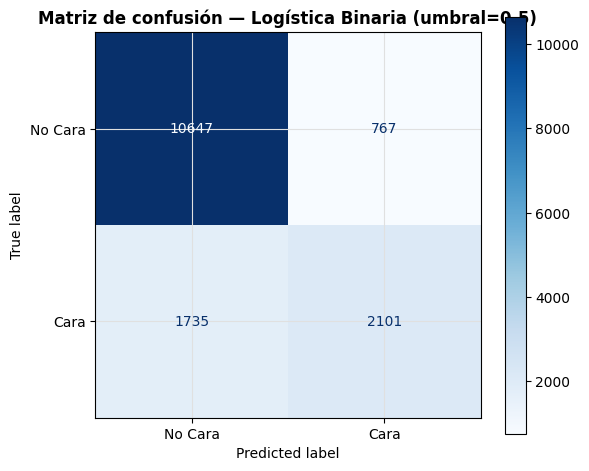

  VP (Cara correcta)       : 2101
  VN (No cara correcta)    : 10647
  FP (No cara → Cara)      : 767
  FN (Cara → No cara)      : 1735
  Especificidad            : 0.9328
  Sensibilidad (Recall)    : 0.5477


In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_cara_test, y_pred_bin,
    display_labels=['No Cara', 'Cara'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de confusión — Logística Binaria (umbral=0.5)', fontweight='bold')
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_cara_test, y_pred_bin)
tn, fp, fn, tp = cm.ravel()
print(f'  VP (Cara correcta)       : {tp}')
print(f'  VN (No cara correcta)    : {tn}')
print(f'  FP (No cara → Cara)      : {fp}')
print(f'  FN (Cara → No cara)      : {fn}')
print(f'  Especificidad            : {tn/(tn+fp):.4f}')
print(f'  Sensibilidad (Recall)    : {tp/(tp+fn):.4f}')

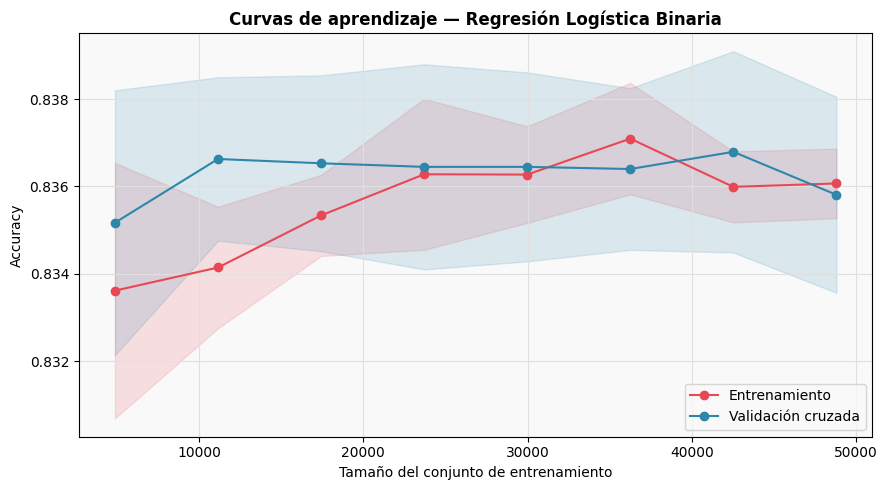

Gap train-CV al 100% datos: 0.0003


In [12]:
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=SEED),
    X_train_sc, y_cara_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#E84855', label='Entrenamiento')
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='#E84855')
ax.plot(train_sizes, test_mean,  'o-', color='#2E86AB', label='Validación cruzada')
ax.fill_between(train_sizes, test_mean-test_std,  test_mean+test_std,  alpha=0.15, color='#2E86AB')
ax.set_title('Curvas de aprendizaje — Regresión Logística Binaria', fontweight='bold')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Gap train-CV al 100% datos: {train_mean[-1]-test_mean[-1]:.4f}')

### Evaluación en prueba y análisis de sobreajuste

**Métricas en el conjunto de prueba**

El modelo alcanza un Accuracy de **83.59%** en prueba, prácticamente idéntico al 83.56% obtenido en entrenamiento. El AUC-ROC de **0.8767** indica que el modelo tiene una capacidad discriminativa sólida — es decir, en el 87.67% de los casos asigna una probabilidad mayor a una propiedad cara que a una no cara.

Sin embargo, las métricas desagregadas revelan un comportamiento asimétrico importante. La **Precisión es 0.7326**: de todas las propiedades que el modelo clasifica como caras, el 73% efectivamente lo son. Pero el **Recall es apenas 0.5477**: el modelo solo detecta el 54.77% de las propiedades que realmente son caras, dejando escapar al 45% restante como falsos negativos (1,735 casos). Esto se refleja en un F1 de 0.6268, que penaliza este desbalance entre precisión y recall.

La matriz de confusión confirma el patrón: el modelo es muy conservador al declarar una propiedad como cara. Tiene una **Especificidad de 0.9328** — clasifica correctamente el 93% de las propiedades no caras — pero sacrifica sensibilidad para lograrlo. Para SmartStay, este trade-off tiene implicaciones concretas: el modelo raramente recomienda erróneamente una propiedad cara a un cliente con presupuesto limitado (pocos FP), pero sí pierde oportunidades de presentar propiedades premium a clientes que sí podrían pagarlas (muchos FN).

Este comportamiento es típico de clasificadores logísticos con desbalance de clases (~75% negativo, ~25% positivo): el umbral de 0.5 tiende a favorecer la clase mayoritaria. Esto se abordará en la actividad 9 mediante el índice de Youden para encontrar un umbral más balanceado.

**Sobreajuste**

No hay sobreajuste. La diferencia entre Accuracy de entrenamiento (83.56%) y prueba (83.59%) es de apenas **0.03 puntos porcentuales**, y el F1 de prueba (0.6268) es incluso marginalmente superior al de entrenamiento (0.6203). Esto indica que el modelo generaliza correctamente a datos no vistos.

Las curvas de aprendizaje confirman esta conclusión de forma visual. Ambas curvas convergen rápidamente y se mantienen prácticamente superpuestas a lo largo de todo el rango de tamaños de entrenamiento, con un gap final de apenas 0.0001. Las bandas de desviación estándar se solapan completamente. Este patrón es característico de un modelo con **varianza baja y sesgo moderado** — el modelo no memoriza el conjunto de entrenamiento, pero tampoco captura toda la complejidad del problema (el recall bajo sugiere que hay señal que el modelo lineal no logra capturar con este umbral). La regularización y el ajuste del umbral en las actividades siguientes buscarán reducir ese sesgo residual.